# OCHA impact data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from io import BytesIO

import ocha_stratus as stratus
import pandas as pd

from src.constants import ISO3, PROJECT_PREFIX

In [5]:
adm2 = stratus.codab.load_codab_from_fieldmaps(iso3=ISO3.lower(), admin_level=2)

In [10]:
adm2

,fid,adm2_id,adm2_src,adm2_name,adm2_name1,adm2_name2,adm1_id,adm1_src,adm1_name,adm1_name1,...,region2_nm,region1_cd,region1_nm,status_cd,status_nm,wld_date,wld_update,wld_view,wld_notes,geometry
0,8677,CAF-20230404-01-1,CF111,Bimbo,NaN,NaN,CAF-20230404-01,CF11,Ombella M'Poko,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((18.51416 3.90527, 18.52944 3.9..."
1,8678,CAF-20230404-01-2,CF112,Damara,NaN,NaN,CAF-20230404-01,CF11,Ombella M'Poko,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((18.8255 4.5683, 18.82575 4.568..."
2,8679,CAF-20230404-01-3,CF113,Bogangolo,NaN,NaN,CAF-20230404-01,CF11,Ombella M'Poko,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((18.60565 5.63586, 18.60333 5.6..."
3,8680,CAF-20230404-01-4,CF114,Boali,NaN,NaN,CAF-20230404-01,CF11,Ombella M'Poko,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((17.68527 4.52583, 17.69484 4.5..."
4,8681,CAF-20230404-01-5,CF115,Bossembélé,NaN,NaN,CAF-20230404-01,CF11,Ombella M'Poko,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((17.53 4.64666, 17.53721 4.6069..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,8744,CAF-20230404-16-1,CF631,Obo,NaN,NaN,CAF-20230404-16,CF63,Haut-Mbomou,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((26.157 5.25383, 26.15714 5.253..."
68,8745,CAF-20230404-16-2,CF632,Bambouti,NaN,NaN,CAF-20230404-16,CF63,Haut-Mbomou,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((26.78568 5.9896, 26.78557 5.98..."
69,8746,CAF-20230404-16-3,CF633,Zémio,NaN,NaN,CAF-20230404-16,CF63,Haut-Mbomou,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((25.67429 5.31191, 25.67436 5.3..."
70,8747,CAF-20230404-16-4,CF634,Djéma,NaN,NaN,CAF-20230404-16,CF63,Haut-Mbomou,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((26.12001 5.66347, 26.1288 5.66..."


<Axes: >

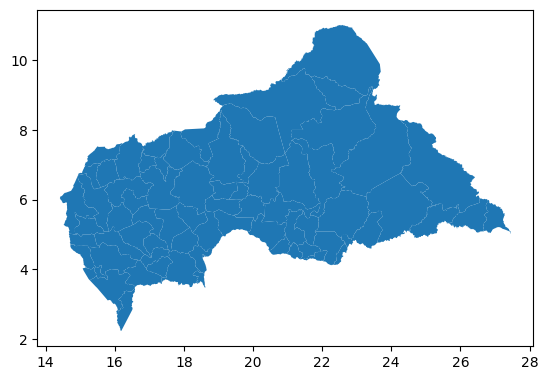

In [7]:
adm2.plot()

In [ ]:
blob_name = f"{PROJECT_PREFIX}/raw/ocha/OCHA CAR_DONNEES-INONDATIONS_DATA_COMPIL_2023OLDOK.xlsx"

df_impact = pd.read_excel(BytesIO(stratus.load_blob_data(blob_name)))

In [17]:
# load all sheets
xls = pd.ExcelFile(BytesIO(stratus.load_blob_data(blob_name)))
sheet_names = xls.sheet_names
sheets = {sheet_name: xls.parse(sheet_name) for sheet_name in sheet_names}
for sheet_name, sheet in sheets.items():
    print(f"Sheet name: {sheet_name}")
    print(sheet.head())
    print("\n")

Sheet name: Population
      Préfecture Pcode Pref Sous-Préfecture Pcode Sous-Pref  Pop 2022 HNO
0   Nana-Mambéré       CF22            Abba           CF224       31257.0
1    Basse-Kotto       CF61         Alindao           CF612      125040.0
2  Mambéré-Kadeï       CF21      Amada-Gaza           CF214       15151.0
3   Nana-Mambéré       CF22          Baboua           CF223       77278.0
4          Ouaka       CF43          Bakala           CF432       11492.0


Sheet name: Sheet8
       Préfecture Sous-préfecture           Commune Type localité  \
0          Bangui          Bangui  Arrondissement 2           NaN   
1          Bangui          Bangui  Arrondissement 6           NaN   
2  Ombella-M'Poko           Bimbo             Bimbo           NaN   
3  Ombella-M'Poko           Bimbo             Bimbo           NaN   
4  Ombella-M'Poko           Bimbo             Bimbo           NaN   

   Population HNO                                        Localité(s)  \
0        812407.0    Mpok

In [19]:
xls.sheet_names

['Population',
 'Sheet8',
 'Personnes affectées-Impacts',
 'Sheet2',
 'Correspondance Data',
 'REPONSE_INONDATION_2024',
 'Admin_',
 'SEVERITE ICC',
 'ANALYSE_OK',
 'Admin-New',
 'Affectes_mois_annee',
 'Affectee_Annee_ok',
 'DATA FOR PBI',
 'Sheet7',
 'Individus_affecte_par_an',
 'Data_affectee_annee',
 'affecte_par_an',
 "En cours d'intégration",
 'Org',
 'admin3_level',
 'Réponses sectorielles',
 'Sheet3',
 'Analyse',
 'Sheet5',
 'Sheet6',
 'Sheet1',
 '3W OP',
 'Admin',
 'Organization']

In [18]:
xls

In [16]:
df_impact

,Préfecture,Pcode Pref,Sous-Préfecture,Pcode Sous-Pref,Pop 2022 HNO
0,Nana-Mambéré,CF22,Abba,CF224,31257.0
1,Basse-Kotto,CF61,Alindao,CF612,125040.0
2,Mambéré-Kadeï,CF21,Amada-Gaza,CF214,15151.0
3,Nana-Mambéré,CF22,Baboua,CF223,77278.0
4,Ouaka,CF43,Bakala,CF432,11492.0
...,...,...,...,...,...
67,Mambéré-Kadeï,CF21,Sosso-Nakombo,CF215,18449.0
68,Haute-Kotto,CF52,Yalinga,CF523,4562.0
69,Ombella-M'Poko,CF11,Yaloké,CF116,82678.0
70,Basse-Kotto,CF61,Zangba,CF615,50815.0


In [14]:
df_impact.merge(adm2, left_on="Pcode Sous-Pref", right_on="adm2_src")

,Préfecture,Pcode Pref,Sous-Préfecture,Pcode Sous-Pref,Pop 2022 HNO,fid,adm2_id,adm2_src,adm2_name,adm2_name1,...,region2_nm,region1_cd,region1_nm,status_cd,status_nm,wld_date,wld_update,wld_view,wld_notes,geometry
0,Nana-Mambéré,CF22,Abba,CF224,31257.0,8698,CAF-20230404-04-4,CF224,Abba,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((15.48654 5.28643, 15.48307 5.2..."
1,Basse-Kotto,CF61,Alindao,CF612,125040.0,8734,CAF-20230404-14-2,CF612,Alindao,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((21.09661 4.66076, 21.09744 4.6..."
2,Mambéré-Kadeï,CF21,Amada-Gaza,CF214,15151.0,8691,CAF-20230404-03-4,CF214,Amada-Gaza,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((14.72254 4.70658, 14.72258 4.7..."
3,Nana-Mambéré,CF22,Baboua,CF223,77278.0,8697,CAF-20230404-04-3,CF223,Baboua,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((14.68116 5.01171, 14.68124 5.0..."
4,Ouaka,CF43,Bakala,CF432,11492.0,8722,CAF-20230404-10-2,CF432,Bakala,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((20.71616 6.22168, 20.70538 6.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Mambéré-Kadeï,CF21,Sosso-Nakombo,CF215,18449.0,8692,CAF-20230404-03-5,CF215,Sosso-Nakombo,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((15.79417 3.70409, 15.79964 3.7..."
68,Haute-Kotto,CF52,Yalinga,CF523,4562.0,8730,CAF-20230404-12-3,CF523,Yalinga,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((23.39722 6.2125, 23.40388 6.21..."
69,Ombella-M'Poko,CF11,Yaloké,CF116,82678.0,8682,CAF-20230404-01-6,CF116,Yaloké,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((17.02194 5.0461, 17.0375 5.024..."
70,Basse-Kotto,CF61,Zangba,CF615,50815.0,8737,CAF-20230404-14-5,CF615,Zangba,NaN,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,NaN,"MULTIPOLYGON (((21.03332 4.81638, 21.02969 4.8..."


In [8]:
df_impact

NameError: name 'df_impact' is not defined